<a href="https://colab.research.google.com/github/srilatha36/BDA-ASSIGNMENT2_075/blob/main/BDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BDA_Assignment").getOrCreate()

print("Spark Ready ✅")

Spark Ready ✅


1. CLASSIFICATION (Titanic + Metrics + Visualization)


Accuracy: 0.7980295566502463
F1 Score: 0.7960940812392638
Precision: 0.7974232349812898
Recall: 0.7980295566502464
Confusion Matrix:
+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       1|       0.0|   25|
|       0|       1.0|   16|
|       0|       0.0|  102|
|       1|       1.0|   60|
+--------+----------+-----+



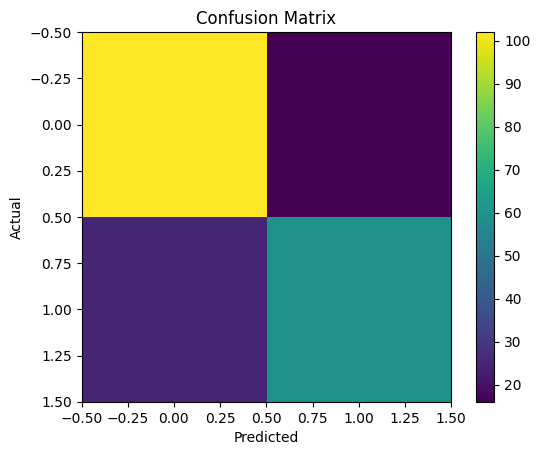

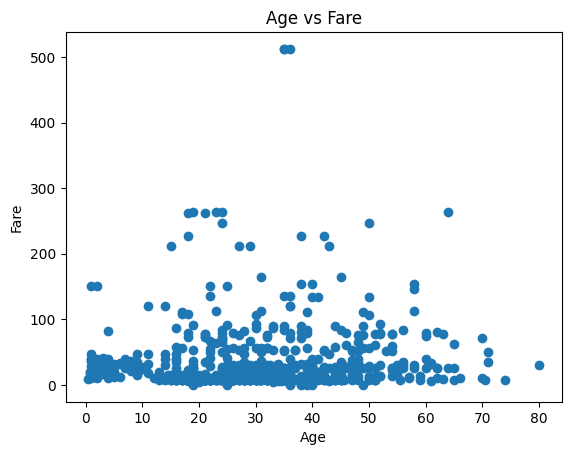

In [3]:
# Load dataset
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

spark_df = spark.createDataFrame(df)

# Preprocessing
from pyspark.ml.feature import StringIndexer, VectorAssembler

spark_df = spark_df.select("Pclass", "Sex", "Age", "Fare", "Survived").dropna()

indexer = StringIndexer(inputCol="Sex", outputCol="SexIndex")
spark_df = indexer.fit(spark_df).transform(spark_df)

assembler = VectorAssembler(
    inputCols=["Pclass","SexIndex","Age","Fare"],
    outputCol="features"
)

data = assembler.transform(spark_df).select("features","Survived")

# Split
train, test = data.randomSplit([0.7,0.3])

# Model
from pyspark.ml.classification import LogisticRegression
model = LogisticRegression(labelCol="Survived").fit(train)

pred = model.transform(test)

# Metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="Survived")

print("Accuracy:", evaluator.setMetricName("accuracy").evaluate(pred))
print("F1 Score:", evaluator.setMetricName("f1").evaluate(pred))
print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(pred))

# Confusion Matrix
print("Confusion Matrix:")
pred.groupBy("Survived", "prediction").count().show()

# Visualization - Confusion Matrix
pdf = pred.select("Survived","prediction").toPandas()
cm = pd.crosstab(pdf['Survived'], pdf['prediction'])

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# Extra Visualization
pdf2 = spark_df.toPandas()
plt.scatter(pdf2["Age"], pdf2["Fare"])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

2. CLUSTERING (K-Means + Metrics + Visualization)

Silhouette Score: 0.735659605433223
+----------+-----+
|prediction|count|
+----------+-----+
|         1|   50|
|         2|   38|
|         0|   62|
+----------+-----+



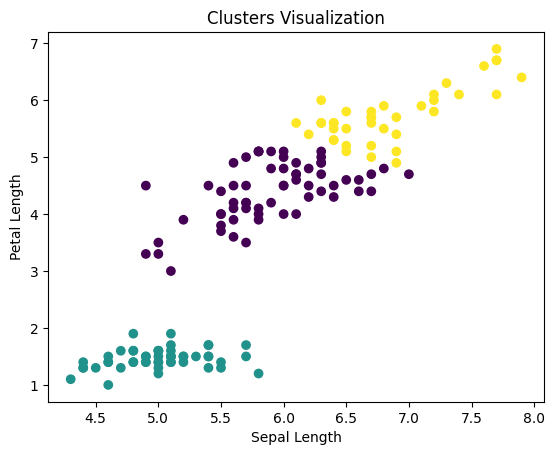

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

spark_df = spark.createDataFrame(df)

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["sepal_length","sepal_width","petal_length","petal_width"],
    outputCol="features"
)

data = assembler.transform(spark_df)

# Model
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3)
model = kmeans.fit(data)

pred = model.transform(data)

# Silhouette Score
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()
print("Silhouette Score:", evaluator.evaluate(pred))

# Cluster Distribution
pred.groupBy("prediction").count().show()

# Visualization
pdf = pred.toPandas()

plt.scatter(pdf["sepal_length"], pdf["petal_length"], c=pdf["prediction"])
plt.title("Clusters Visualization")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

3. RECOMMENDATION SYSTEM (MovieLens + RMSE + Visualization)


--2026-04-16 16:48:25--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  2.56MB/s    in 1.8s    

2026-04-16 16:48:29 (2.56 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.ba

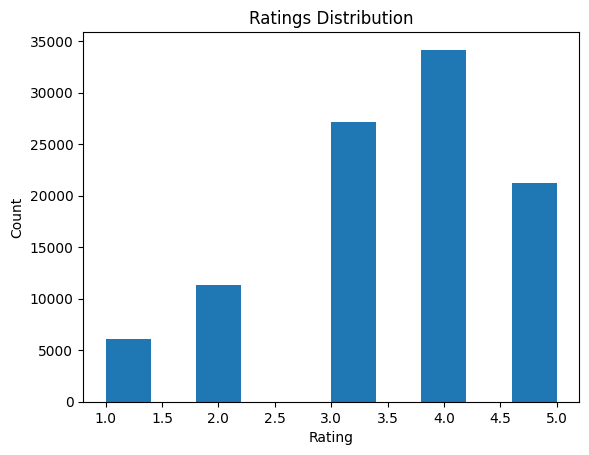

In [5]:
import matplotlib.pyplot as plt

# Download dataset
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -o ml-100k.zip

# Load data
ratings = spark.read.csv("/content/ml-100k/u.data", sep="\t", inferSchema=True)
ratings = ratings.toDF("userId","movieId","rating","timestamp")

from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop"
)

model = als.fit(ratings)

# RMSE
pred = model.transform(ratings)

from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

print("RMSE:", evaluator.evaluate(pred))

# Recommendations
user_recs = model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)

# Visualization - Ratings Distribution
pdf = ratings.toPandas()

plt.hist(pdf["rating"])
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()